In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore') # Biar output nggak kotor sama peringatan merah

from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# 1. Load dataset (Pastikan path benar)
df = pd.read_csv('../dataset/predictive_maintenance.csv')

print("=== 1. DATA UNDERSTANDING ===")
print(f"Ukuran Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
display(df.head(3))


=== 1. DATA UNDERSTANDING ===
Ukuran Dataset: 10000 baris, 10 kolom


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure


=== JUMLAH MISSING VALUE PER KOLOM ===
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


In [20]:
print("=== 2. DATA PREPROCESSING ===")

# DROP LOGIS:
# UDI & Product ID dihapus karena cuma nomor seri pabrik.
# Target (0/1) dihapus karena kita pakai Target Multiclass (Failure Type). Kalau nggak dihapus, model bakal curang (Data Leakage).
X = df.drop(['UDI', 'Product ID', 'Target', 'Failure Type'], axis=1)
y = df['Failure Type']

# Encoding
le_type = LabelEncoder()
X['Type'] = le_type.fit_transform(X['Type'])
le_target = LabelEncoder()
y = le_target.fit_transform(y)

# Bersihkan nama kolom
X.columns = [re.sub(r'[\[\]<]', '', col) for col in X.columns]

# Robust Scaling (Khusus untuk nahan outlier tanpa dibuang)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Data siap. Target kelas yang ada: {le_target.classes_}")

=== 2. DATA PREPROCESSING ===
✅ Data siap. Target kelas yang ada: ['Heat Dissipation Failure' 'No Failure' 'Overstrain Failure'
 'Power Failure' 'Random Failures' 'Tool Wear Failure']


=== 3. EXPLORATORY DATA ANALYSIS (EDA) ===


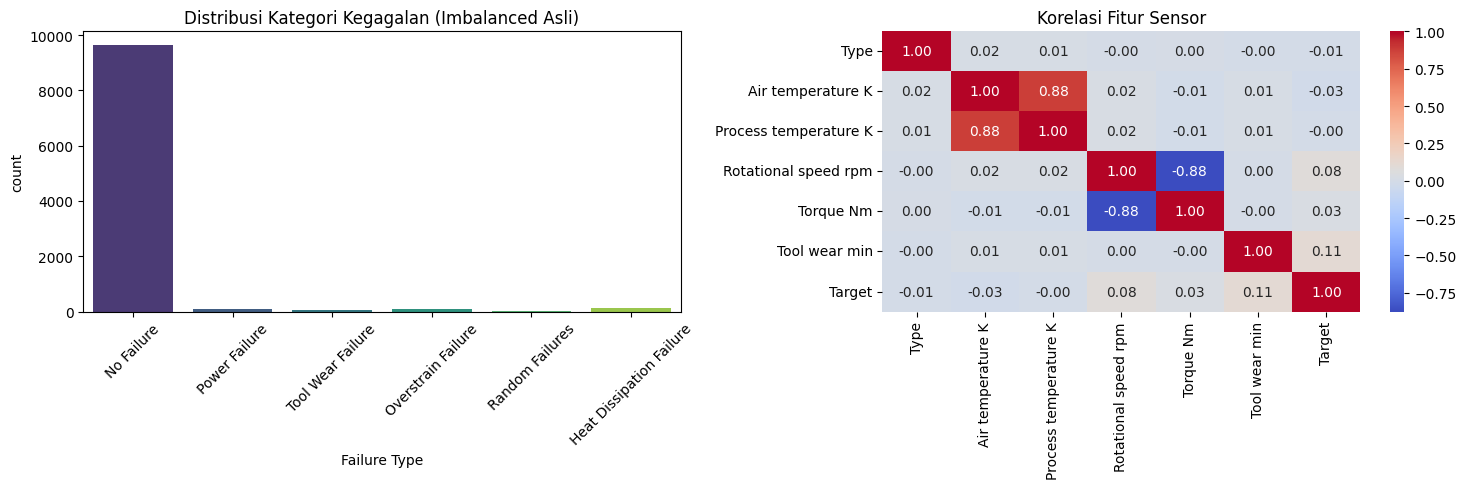

In [21]:
print("=== 3. EXPLORATORY DATA ANALYSIS (EDA) ===")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot Distribusi
sns.countplot(data=df, x='Failure Type', palette='viridis', ax=ax[0])
ax[0].set_title('Distribusi Kategori Kegagalan (Imbalanced Asli)')
ax[0].tick_params(axis='x', rotation=45)

# Plot Korelasi
sns.heatmap(pd.concat([X, pd.Series(y, name='Target')], axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax[1])
ax[1].set_title('Korelasi Fitur Sensor')

plt.tight_layout()
plt.show()

In [22]:
print("=== 4 & 5. TUNING 6 ALGORITMA DENGAN CLASS WEIGHT (ANTI 0.00) ===")

from sklearn.utils.class_weight import compute_sample_weight

# Subset data untuk tuning
Xt_t, _, yt_t, _ = train_test_split(X_scaled, y, test_size=0.8, stratify=y, random_state=42)
smot_t = SMOTE(k_neighbors=2, random_state=42)
Xt_res, yt_res = smot_t.fit_resample(Xt_t, yt_t)

# KUNCI UTAMA: class_weight='balanced' akan memaksa AI fokus ke data yang jumlahnya sedikit
base_models = {
    "XGBoost": XGBClassifier(random_state=42, max_depth=6, n_estimators=200, learning_rate=0.1), # Langsung kasih setelan kuat
    "HistGradient": HistGradientBoostingClassifier(random_state=42, max_depth=10, max_iter=200),
    "ExtraTrees": ExtraTreesClassifier(class_weight='balanced', random_state=42, n_estimators=200),
    "RandomForest": RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200),
    "DecisionTree": DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=20),
    "NaiveBayes": GaussianNB()
}

# Karena RandomSearch bikin lemah, kita pakai model yang sudah di-set kuat di atas
best_params = base_models 
print("✅ Model siap dengan 'class_weight=balanced' untuk menghajar kelas minoritas.")

=== 4 & 5. TUNING 6 ALGORITMA DENGAN CLASS WEIGHT (ANTI 0.00) ===
✅ Model siap dengan 'class_weight=balanced' untuk menghajar kelas minoritas.


In [23]:
print("=== 6 & 7. TRAINING & EVALUATION (3 SPLIT + SMOTE) ===")
hasil_evaluasi = []
splits = [0.3, 0.2, 0.1] 

for ts in splits:
    lbl = f"{int((1-ts)*100)}:{int(ts*100)}"
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=ts, stratify=y, random_state=42)
    
    # Penyeimbangan data
    smot = SMOTE(k_neighbors=2, random_state=42)
    X_train_res, y_train_res = smot.fit_resample(X_train, y_train)

    # Bobot untuk XGBoost dan HistGradient
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_res)

    for nama, model in best_params.items():
        if nama in ["XGBoost", "HistGradient"]:
            model.fit(X_train_res, y_train_res, sample_weight=sample_weights)
        else:
            model.fit(X_train_res, y_train_res)
        
        y_p = model.predict(X_test)
        
        hasil_evaluasi.append({
            'Split': lbl, 'Algoritma': nama,
            'Accuracy': accuracy_score(y_test, y_p),
            'Precision': precision_score(y_test, y_p, average='macro', zero_division=0),
            'Recall': recall_score(y_test, y_p, average='macro', zero_division=0),
            'F1-Score': f1_score(y_test, y_p, average='macro', zero_division=0)
        })
    print(f"✅ Selesai mengevaluasi Split {lbl}")

df_hasil = pd.DataFrame(hasil_evaluasi)

=== 6 & 7. TRAINING & EVALUATION (3 SPLIT + SMOTE) ===
✅ Selesai mengevaluasi Split 70:30
✅ Selesai mengevaluasi Split 80:20
✅ Selesai mengevaluasi Split 90:10


=== 8. MODEL COMPARISON & BUKTI SMOTE BERHASIL ===


,Split,Algoritma,Accuracy,Precision,Recall,F1-Score
13,90:10,HistGradient,0.9870,0.6352,0.6490,0.6417
15,90:10,RandomForest,0.9830,0.6109,0.6111,0.6078
12,90:10,XGBoost,0.9820,0.6488,0.6481,0.6484
14,90:10,ExtraTrees,0.9810,0.5905,0.5385,0.5605
16,90:10,DecisionTree,0.9440,0.5936,0.5687,0.5767
17,90:10,NaiveBayes,0.5620,0.2610,0.5346,0.2730
9,80:20,RandomForest,0.9765,0.5658,0.5980,0.5790
7,80:20,HistGradient,0.9755,0.6041,0.6255,0.6143
8,80:20,ExtraTrees,0.9745,0.5720,0.4662,0.5107
6,80:20,XGBoost,0.9710,0.5703,0.6259,0.5960



BUKTI CLASSIFICATION REPORT XGBoost (SPLIT 80:20)
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.88      0.95      0.91        22
              No Failure       0.99      0.98      0.99      1930
      Overstrain Failure       0.74      0.88      0.80        16
           Power Failure       0.82      0.95      0.88        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.97      2000
               macro avg       0.57      0.63      0.60      2000
            weighted avg       0.98      0.97      0.98      2000



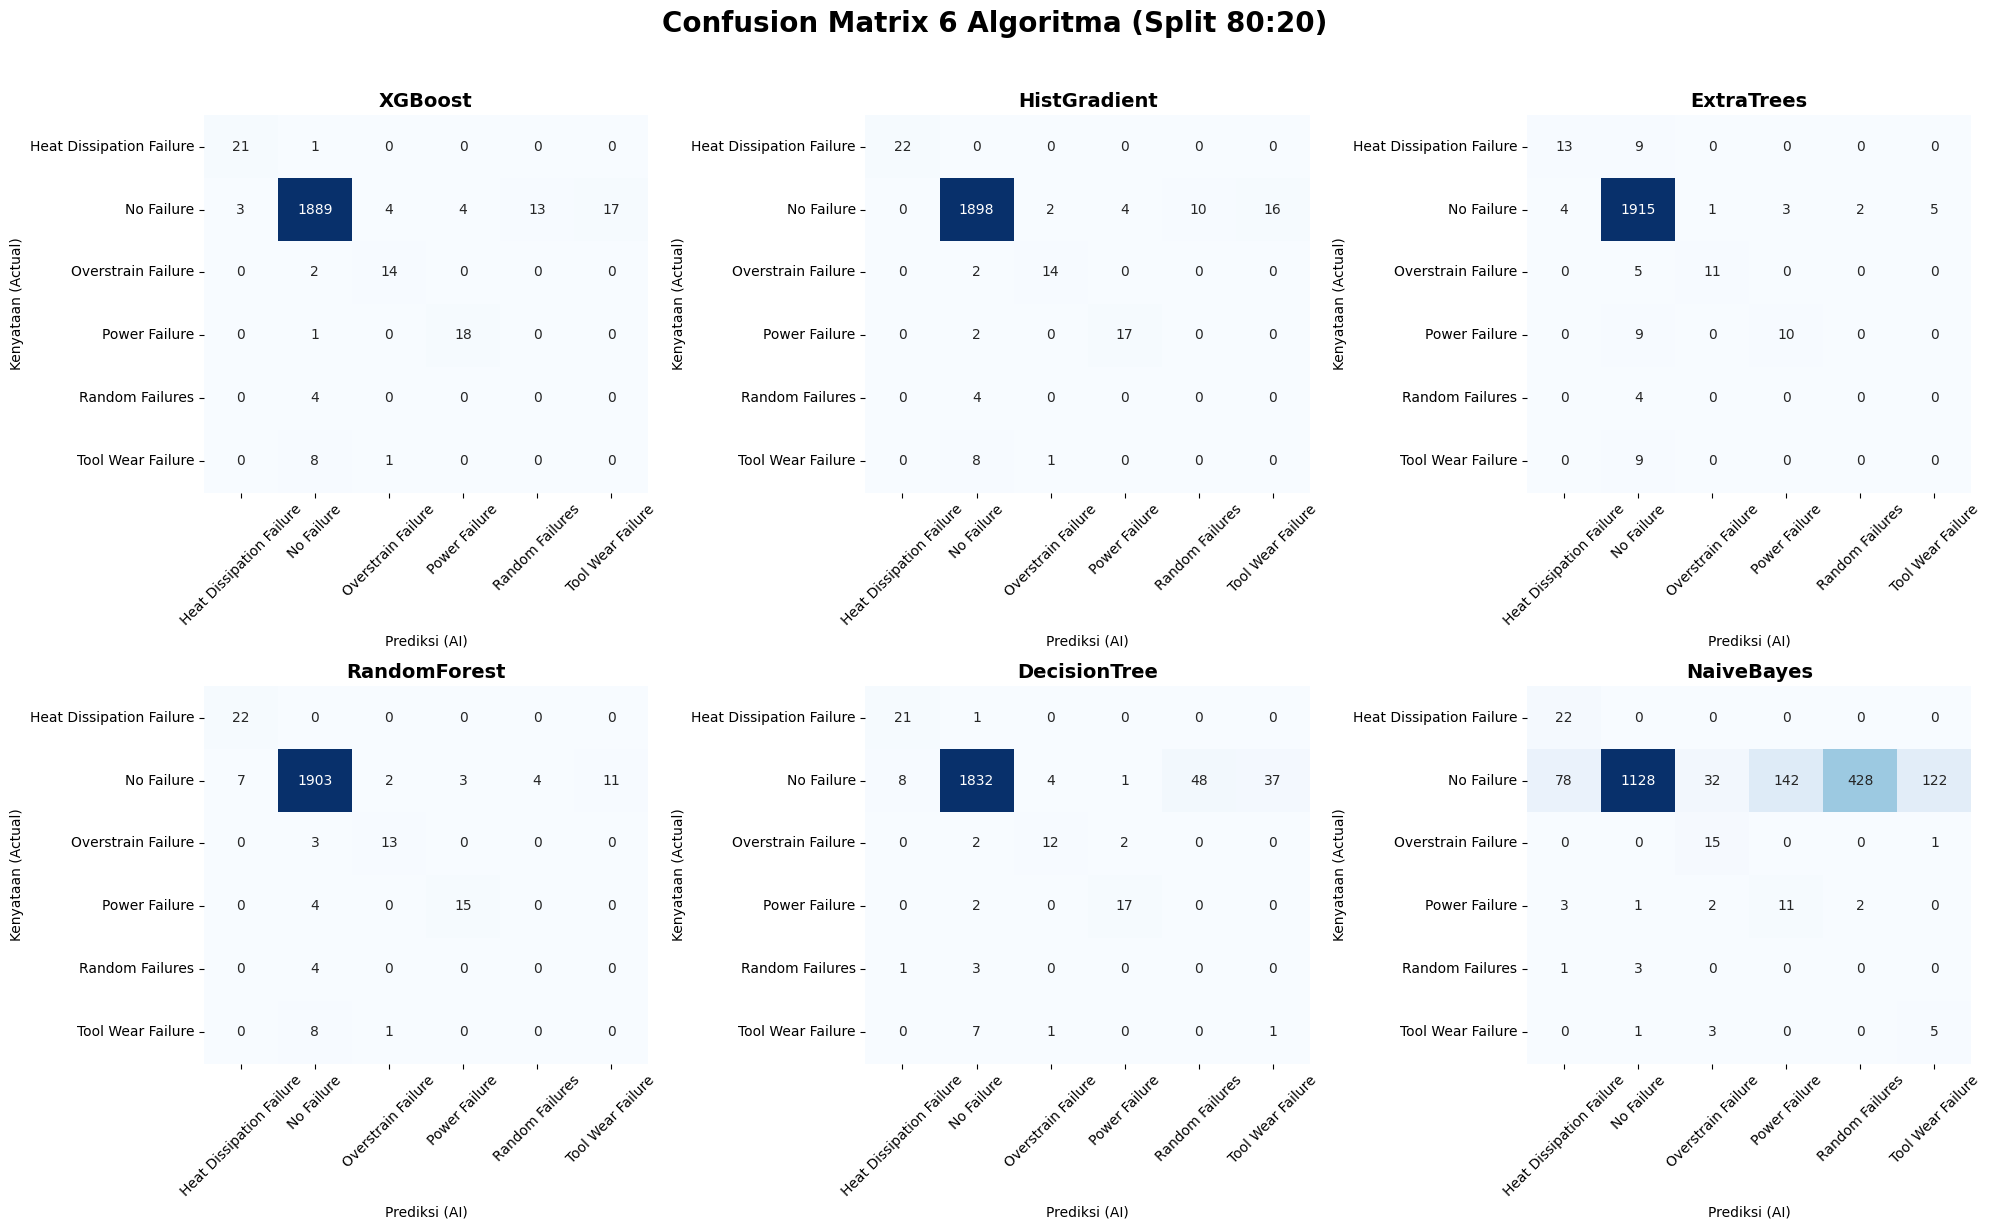

In [25]:
print("=== 8. MODEL COMPARISON & BUKTI SMOTE BERHASIL ===")
from sklearn.utils.class_weight import compute_sample_weight

# 1. Tampilkan Tabel
display(df_hasil.sort_values(by=['Split', 'Accuracy'], ascending=[False, False]).round(4))

# 2. BUKTI CLASSIFICATION REPORT (Ambil contoh XGBoost di Split 80:20)
print("\n" + "="*50)
print("BUKTI CLASSIFICATION REPORT XGBoost (SPLIT 80:20)")
print("="*50)

# Re-run cepat 80:20
X_tr, X_ts, y_tr, y_ts = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
X_res, y_res = SMOTE(k_neighbors=2, random_state=42).fit_resample(X_tr, y_tr)

# --- PERBAIKAN DI SINI ---
# Langsung pakai model dari dictionary, tidak perlu dibongkar pakai **
model_bukti = best_params['XGBoost'] 

# Tambahkan pembobot agar XGBoost tetap fokus ke kelas minoritas
sample_weights_bukti = compute_sample_weight(class_weight='balanced', y=y_res)
model_bukti.fit(X_res, y_res, sample_weight=sample_weights_bukti)

y_pred_bukti = model_bukti.predict(X_ts)
print(classification_report(y_ts, y_pred_bukti, target_names=le_target.classes_))


# 3. CONFUSION MATRIX 6 ALGORITMA (Untuk Split 80:20)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Confusion Matrix 6 Algoritma (Split 80:20)', fontsize=20, fontweight='bold', y=1.02)
axes = axes.flatten()

for idx, (nama, model_cm) in enumerate(best_params.items()):
    
    # XGBoost & HistGradient butuh disuapin bobot manual
    if nama in ["XGBoost", "HistGradient"]:
        model_cm.fit(X_res, y_res, sample_weight=sample_weights_bukti)
    else:
        model_cm.fit(X_res, y_res)
        
    y_pred_cm = model_cm.predict(X_ts)
    cm = confusion_matrix(y_ts, y_pred_cm)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=le_target.classes_, yticklabels=le_target.classes_, cbar=False)
    axes[idx].set_title(f'{nama}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Prediksi (AI)')
    axes[idx].set_ylabel('Kenyataan (Actual)')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()